In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
data = {
    "Weight":[79,69,73,95,82,55,69,71,64,69,
              85,77,62,58,90,72,67,75,81,60,
              68,74,88,66,79,53,57,92,70,83],

    "Height":[1.80,1.68,1.82,1.70,1.87,1.55,1.50,1.78,1.67,1.64,
              1.85,1.79,1.60,1.58,1.90,1.75,1.69,1.81,1.84,1.62,
              1.66,1.76,1.88,1.65,1.83,1.54,1.57,1.91,1.72,1.86],

    "Age":[35,39,25,60,27,18,89,42,16,52,
           31,45,20,23,55,34,28,37,41,21,
           26,30,49,24,36,19,22,58,33,44],

    "Gender":[
        "Male","Male","Male","Male","Male",
        "Female","Female","Female","Female","Female",
        "Male","Male","Female","Female","Male",
        "Male","Female","Male","Male","Female",
        "Female","Male","Male","Female","Male",
        "Female","Female","Male","Female","Male"
    ]
}

df = pd.DataFrame(data)

df.head()

,Weight,Height,Age,Gender
0,79,1.80,35,Male
1,69,1.68,39,Male
2,73,1.82,25,Male
3,95,1.70,60,Male
4,82,1.87,27,Male


In [4]:
df.to_csv("Body_Weight_Dataset.csv", index=False)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!


In [5]:
df

,Weight,Height,Age,Gender
0,79,1.80,35,Male
1,69,1.68,39,Male
2,73,1.82,25,Male
3,95,1.70,60,Male
4,82,1.87,27,Male
5,55,1.55,18,Female
6,69,1.50,89,Female
7,71,1.78,42,Female
8,64,1.67,16,Female
9,69,1.64,52,Female


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  30 non-null     int64  
 1   Height  30 non-null     float64
 2   Age     30 non-null     int64  
 3   Gender  30 non-null     object 
dtypes: float64(1), int64(2), object(1)
memory usage: 1.1+ KB


In [7]:
df.isnull().sum()

,0
Weight,0
Height,0
Age,0
Gender,0


In [8]:
encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

df.head()

,Weight,Height,Age,Gender
0,79,1.80,35,1
1,69,1.68,39,1
2,73,1.82,25,1
3,95,1.70,60,1
4,82,1.87,27,1


In [9]:
X = df[["Height","Age","Gender"]]

y = df["Weight"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [12]:
y_pred = model.predict(X_test)

print(y_pred)

[91.30117002 76.21559784 62.33652689 80.16854467 61.09796173 69.77238042]


In [13]:
result = pd.DataFrame({
    "Actual Weight":y_test,
    "Predicted Weight":y_pred
})

result

,Actual Weight,Predicted Weight
27,92,91.301170
15,72,76.215598
23,66,62.336527
17,75,80.168545
8,64,61.097962
9,69,69.772380


In [14]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 2.903477380869546
Mean Squared Error : 11.235485882591071
Root Mean Squared Error : 3.3519376310711797
R2 Score : 0.8683341498133859


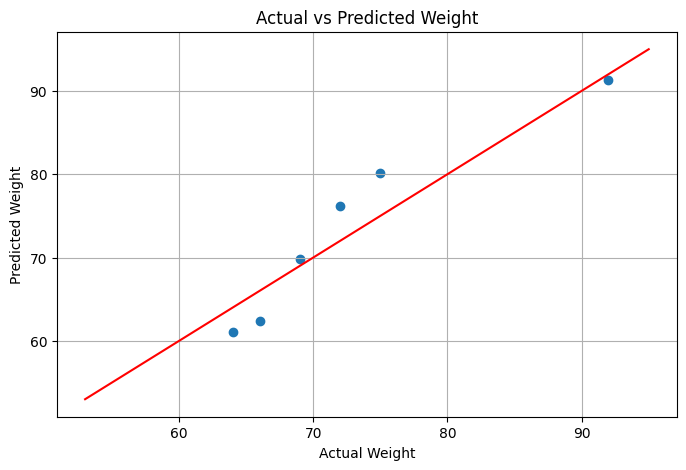

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color='red')

plt.xlabel("Actual Weight")
plt.ylabel("Predicted Weight")
plt.title("Actual vs Predicted Weight")

plt.grid(True)

plt.show()

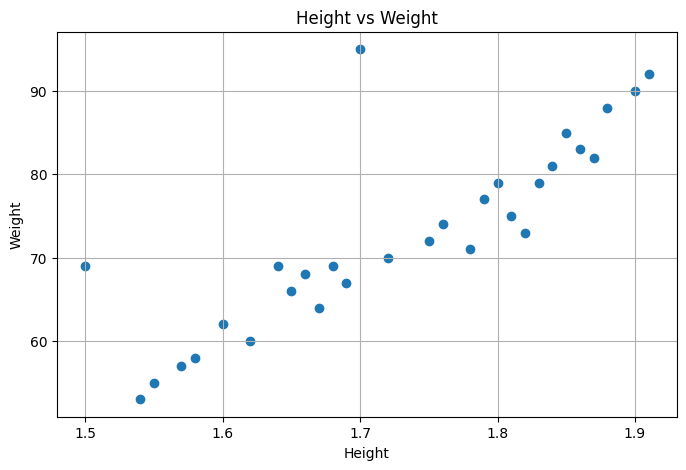

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(df["Height"], df["Weight"])

plt.xlabel("Height")
plt.ylabel("Weight")

plt.title("Height vs Weight")

plt.grid(True)

plt.show()

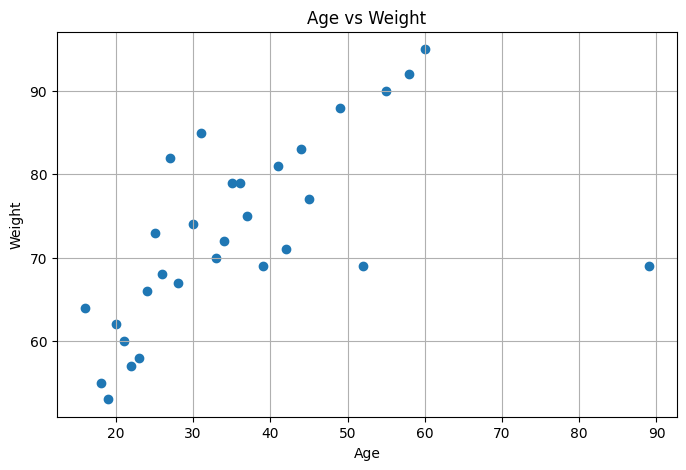

In [17]:
plt.figure(figsize=(8,5))

plt.scatter(df["Age"], df["Weight"])

plt.xlabel("Age")
plt.ylabel("Weight")

plt.title("Age vs Weight")

plt.grid(True)

plt.show()

In [18]:
new_person = [[1.75, 28, 1]]

prediction = model.predict(new_person)

print("Predicted Weight =", prediction[0], "kg")

Predicted Weight = 74.51145510048494 kg


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
